# Text Classification Assignment
## Fake Review Detection using Product Reviews

**Dataset:** [Fake Reviews Dataset – Kaggle](https://www.kaggle.com/datasets/muqaddasejaz/fake-reviews-dataset)  
**GitHub Repository:** https://github.com/uiilya/NLP-Fake-Reviews-Classification  
**Author:** *Dhani Fatih Ilyasa* (23523172)  
**Date:** May 2026

---

### Overview
Online review fraud is a well-documented and growing problem.  
This notebook develops a **binary text classifier** that distinguishes
*fake (computer-generated)* reviews from *genuine (human-written)* reviews
using classical NLP preprocessing, TF-IDF and Word2Vec feature engineering,
and multiple supervised classifiers.



---
## Part 0 – Problem Statement & Article

**Article:** https://digitalsociety.id/2025/01/31/fake-reviews/19009/

**Problem:** Hotel/product platforms are flooded with incentivised or AI-generated
fake reviews that mislead consumers and harm honest vendors.  
Detecting these reviews at scale requires automated text classification.

**Our Solution:** Train a binary classifier (`CG` = computer-generated / fake  vs
`OR` = original / genuine) on a labelled dataset of product reviews, using TF-IDF features fed into Logistic Regression, Naïve Bayes, and SVM.


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Part 1 – Data Collection (10 pts)

### Dataset Description
| Property | Value |
|---|---|
| Source | Kaggle – *Fake Reviews Dataset* (muqaddasejaz) |
| File | `fake reviews dataset.csv` |
| Labels | `CG` = computer-generated (fake), `OR` = original (genuine) |
| Features | `category`, `rating`, `label`, `text_` |

The dataset contains product reviews across several categories,
each labelled as either machine-generated (`CG`) or authentic (`OR`).
We treat this as a **binary text classification** task.


In [23]:
!pip install kagglehub pandas

In [24]:
# ── Part 1: Data Collection ──────────────────────────────────────────────────
import kagglehub
import pandas as pd
import os

# 1. Download the dataset via Kagglehub
print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("muqaddasejaz/fake-reviews-dataset")
print(f"Dataset downloaded to: {path}")

# 2. Automatically locate the CSV file inside the downloaded folder
csv_file_path = None
for file in os.listdir(path):
    if file.endswith('.csv'):
        csv_file_path = os.path.join(path, file)
        break

# 3. Load into Pandas and display the summary
if csv_file_path:
    df = pd.read_csv(csv_file_path)
    print("\n✅ Dataset successfully loaded into Pandas DataFrame!")
    print(f"Dataset Shape: {df.shape}")

    # Display the first few rows and basic info for your assignment summary
    display(df.head())
    print("\nDataset Info:")
    df.info()
else:
    print("❌ Error: No CSV file found in the downloaded dataset folder.")

100%|██████████| 4.78M/4.78M [00:00<00:00, 6.77MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/muqaddasejaz/fake-reviews-dataset/versions/1

✅ Dataset successfully loaded into Pandas DataFrame!
Dataset Shape: (40432, 4)


,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


In [25]:
# ── Dataset statistics ───────────────────────────────────────────────────────
print("=== Dataset Summary ===")
print(df.describe(include='all'))
print()
print("Missing values:")
print(df.isnull().sum())

# Drop rows with missing text
df.dropna(subset=['text_'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\nClean dataset size: {len(df)} rows")


=== Dataset Summary ===
              category        rating  label  \
count            40432  40432.000000  40432   
unique              10           NaN      2   
top     Kindle_Store_5           NaN     CG   
freq              4730           NaN  20216   
mean               NaN      4.256579    NaN   
std                NaN      1.144354    NaN   
min                NaN      1.000000    NaN   
25%                NaN      4.000000    NaN   
50%                NaN      5.000000    NaN   
75%                NaN      5.000000    NaN   
max                NaN      5.000000    NaN   

                                                    text_  
count                                               40432  
unique                                              40412  
top     My dog loves these and it has kept her occupie...  
freq                                                    2  
mean                                                  NaN  
std                                                

---
## Part 2 – Text Preprocessing (20 pts)

We apply five standard preprocessing steps:

1. **Lowercasing** – normalise casing  
2. **Remove punctuation & special characters** – strip noise  
3. **Tokenisation** – split text into word tokens  
4. **Stopword removal** – discard high-frequency non-informative words  
5. **Stemming** – reduce words to their root form (Porter Stemmer)


In [26]:
# ── Part 2: Text Preprocessing ───────────────────────────────────────────────
import re
import nltk

# Download required NLTK data
for resource in ['punkt', 'stopwords', 'punkt_tab']:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

STOP_WORDS = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text: str) -> str:
    """Full preprocessing pipeline for a single review string."""
    # 1. Lowercase
    text = text.lower()
    # 2. Remove punctuation & special characters (keep only letters & spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 3. Tokenise
    tokens = word_tokenize(text)
    # 4. Remove stopwords
    tokens = [t for t in tokens if t not in STOP_WORDS]
    # 5. Stem
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

# Apply to full dataset
df['text_clean'] = df['text_'].apply(preprocess)

# ── Show before / after examples ─────────────────────────────────────────────
print("=== Preprocessing Examples ===\n")
for i in [0, 1, 2]:
    print(f"[{i}] ORIGINAL : {df['text_'][i]}")
    print(f"    CLEANED  : {df['text_clean'][i]}")
    print()


=== Preprocessing Examples ===

[0] ORIGINAL : Love this!  Well made, sturdy, and very comfortable.  I love it!Very pretty
    CLEANED  : love well made sturdi comfort love pretti

[1] ORIGINAL : love it, a great upgrade from the original.  I've had mine for a couple of years
    CLEANED  : love great upgrad origin mine coupl year

[2] ORIGINAL : This pillow saved my back. I love the look and feel of this pillow.
    CLEANED  : pillow save back love look feel pillow



---
## Part 3 – Feature Engineering (10 pts)

### TF-IDF
**TF-IDF** (Term Frequency – Inverse Document Frequency) measures how important
a word is to a document relative to the entire corpus.  
- **TF(t, d)** = count of term *t* in document *d* / total terms in *d*  
- **IDF(t)** = log(N / df(t)), where N = total documents, df(t) = documents containing *t*  
- Words that appear often in one document but rarely across the corpus get high TF-IDF scores.

### Word2Vec
**Word2Vec** (Mikolov et al., 2013) learns dense vector representations (embeddings)
of words by training a shallow neural network to predict a word from its context
(Skip-gram) or predict context from a word (CBOW).  
Words with similar meanings end up close together in the vector space.  
We use the mean of all token vectors in a document as its feature vector.


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 20.1 MB/s eta 0:00:00


In [ ]:
# ── Part 3: Feature Engineering ──────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

# ── 3a. TF-IDF ────────────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['text_clean'])

print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Sample top-10 features: {tfidf.get_feature_names_out()[:10]}")

# Show TF-IDF scores for the first review
import pandas as pd
sample_vec = X_tfidf[0].toarray()[0]
feat_names = tfidf.get_feature_names_out()
top_idx = sample_vec.argsort()[::-1][:10]
print("\nTop TF-IDF terms for review[0]:")
for idx in top_idx:
    if sample_vec[idx] > 0:
        print(f"  '{feat_names[idx]}': {sample_vec[idx]:.4f}")


TF-IDF matrix shape: (40432, 5000)
Sample top-10 features: ['aa' 'abil' 'abl' 'abl find' 'abl get' 'abl put' 'abl use' 'abrupt'
 'absolut' 'absolut love']

Top TF-IDF terms for review[0]:
  'made sturdi': 0.5250
  'comfort love': 0.4845
  'well made': 0.3055
  'love': 0.3008
  'sturdi': 0.2882
  'pretti': 0.2649
  'comfort': 0.2547
  'made': 0.2360
  'well': 0.1791


In [ ]:
# ── 3b. Word2Vec ─────────────────────────────────────────────────────────────
# Tokenised sentences for Word2Vec training
sentences = [text.split() for text in df['text_clean']]

w2v_model = Word2Vec(
    sentences,
    vector_size=100,   # embedding dimensions
    window=5,          # context window
    min_count=2,       # ignore rare tokens
    workers=4,
    seed=42
)
print(f"Word2Vec vocabulary size: {len(w2v_model.wv)}")
print("\nSample similar words to 'product':")
similar = w2v_model.wv.most_similar('product', topn=5)
for word, score in similar:
    print(f"  {word}: {score:.4f}")

# ── Build document vectors by averaging token embeddings ──────────────────────
def doc_vector(text: str, model) -> np.ndarray:
    words = text.split()
    vecs = [model.wv[w] for w in words if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

X_w2v = np.vstack([doc_vector(t, w2v_model) for t in df['text_clean']])
print(f"\nWord2Vec document matrix shape: {X_w2v.shape}")


Word2Vec vocabulary size: 15597

Sample similar words to 'product':
  item: 0.7165
  pleas: 0.6147
  qualiti: 0.6097
  result: 0.6041
  choic: 0.5901

Word2Vec document matrix shape: (40432, 100)


---
## Part 4 – Exploratory Data Analysis & Visualisation (20 pts)

We explore:
1. Class distribution
2. Review length distribution
3. Word clouds per class
4. Top-20 most frequent words (bar plot)


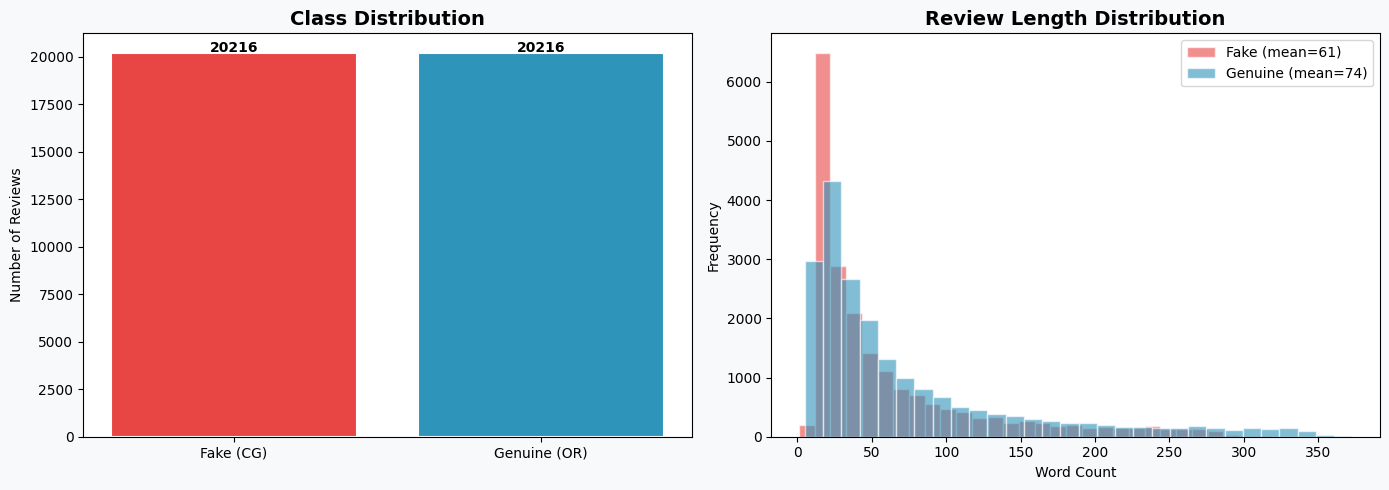

Figure saved: eda_dist.png


In [ ]:
# ── Part 4: EDA & Visualisation ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

# ── Colour palette ────────────────────────────────────────────────────────────
FAKE_COLOR   = '#E84545'
REAL_COLOR   = '#2E94B9'
BG_COLOR     = '#F8F9FA'

# ── 4a. Class distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG_COLOR)

counts = df['label'].value_counts()
axes[0].bar(['Fake (CG)', 'Genuine (OR)'], counts.values,
            color=[FAKE_COLOR, REAL_COLOR], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# ── 4b. Review length distribution ───────────────────────────────────────────
df['word_count'] = df['text_'].apply(lambda x: len(str(x).split()))
df['clean_word_count'] = df['text_clean'].apply(lambda x: len(str(x).split()))

for label, color, ls in [('CG', FAKE_COLOR, '-'), ('OR', REAL_COLOR, '--')]:
    subset = df[df['label'] == label]['word_count']
    axes[1].hist(subset, bins=30, alpha=0.6, color=color,
                 label=f"{'Fake' if label=='CG' else 'Genuine'} (mean={subset.mean():.0f})",
                 edgecolor='white')
axes[1].set_title('Review Length Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: eda_dist.png")


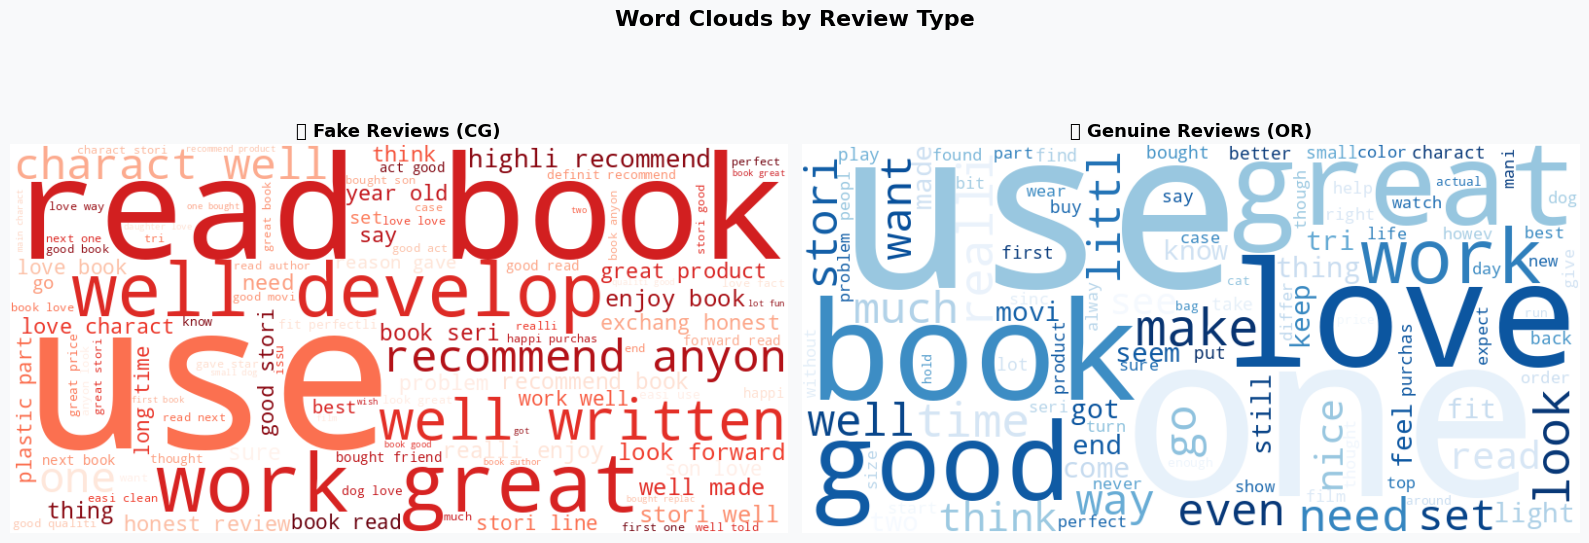

Figure saved: wordclouds.png


In [ ]:
# ── 4c. Word Clouds ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Word Clouds by Review Type', fontsize=16, fontweight='bold', y=1.02)

for ax, label, title, cmap in [
    (axes[0], 'CG', 'Fake Reviews (CG)', 'Reds'),
    (axes[1], 'OR', 'Genuine Reviews (OR)', 'Blues'),
]:
    text_blob = ' '.join(df[df['label'] == label]['text_clean'])
    if text_blob.strip():
        wc = WordCloud(
            width=800, height=400,
            background_color='white',
            colormap=cmap,
            max_words=100,
            contour_width=1,
            contour_color='steelblue'
        ).generate(text_blob)
        ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: wordclouds.png")


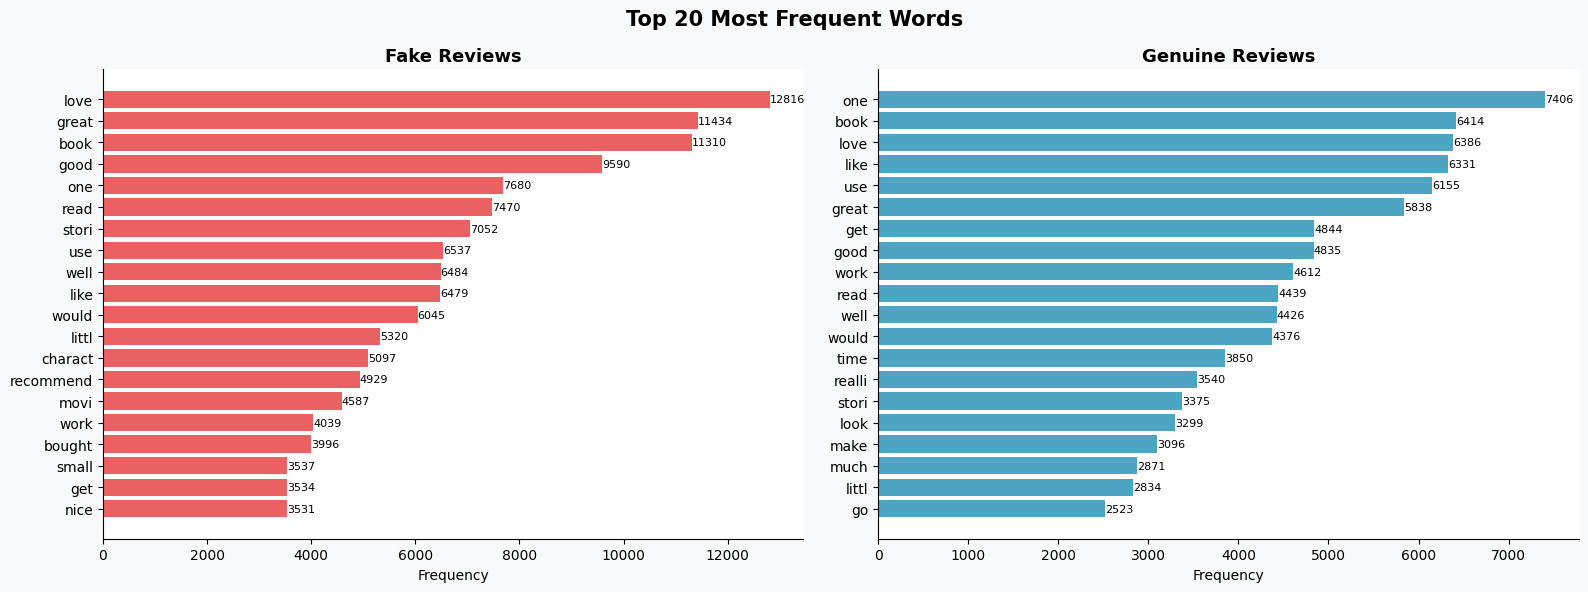

Figure saved: top_words.png


In [ ]:
# ── 4d. Top-20 Words Bar Plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Top 20 Most Frequent Words', fontsize=15, fontweight='bold')

for ax, label, title, color in [
    (axes[0], 'CG', 'Fake Reviews', FAKE_COLOR),
    (axes[1], 'OR', 'Genuine Reviews', REAL_COLOR),
]:
    words = ' '.join(df[df['label'] == label]['text_clean']).split()
    top20 = Counter(words).most_common(20)
    words_list, counts_list = zip(*top20)

    bars = ax.barh(words_list[::-1], counts_list[::-1], color=color, alpha=0.85)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.spines[['top','right']].set_visible(False)
    for bar, count in zip(bars, counts_list[::-1]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                str(count), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: top_words.png")


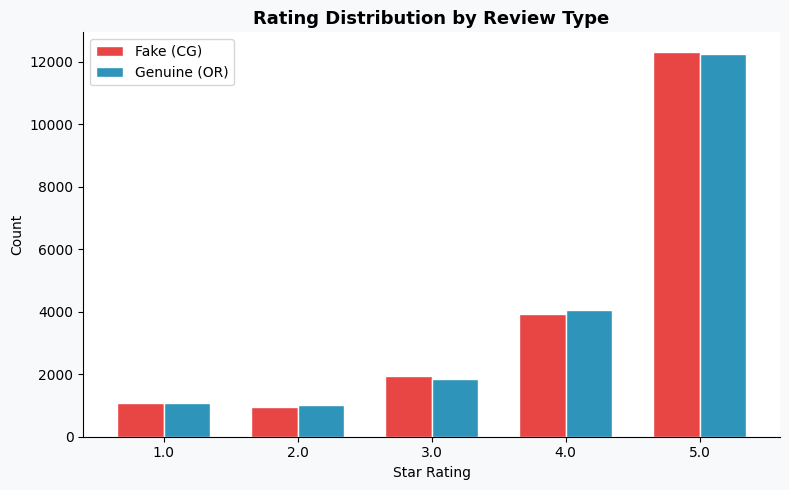

Figure saved: rating_dist.png


In [ ]:
# ── 4e. Rating distribution per class ────────────────────────────────────────
if 'rating' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor(BG_COLOR)
    rating_pivot = df.groupby(['rating', 'label']).size().unstack(fill_value=0)
    rating_pivot.plot(kind='bar', ax=ax,
                      color=[FAKE_COLOR, REAL_COLOR], edgecolor='white', width=0.7)
    ax.set_title('Rating Distribution by Review Type', fontsize=13, fontweight='bold')
    ax.set_xlabel('Star Rating')
    ax.set_ylabel('Count')
    ax.legend(['Fake (CG)', 'Genuine (OR)'])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('rating_dist.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure saved: rating_dist.png")


---
## Part 5 – Text Classification (25 pts)

We train **three classifiers** (Multinomial Naïve Bayes, Logistic Regression, SVM)
on TF-IDF features and compare their performance using:
- Accuracy, Precision, Recall, F1-Score
- Confusion matrix heatmap

We also train a Logistic Regression on Word2Vec features for comparison.


In [ ]:
# ── Part 5: Text Classification ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

# ── Encode labels ─────────────────────────────────────────────────────────────
label_map = {'CG': 1, 'OR': 0}  # 1 = fake, 0 = genuine
y = df['label'].map(label_map).values

# ── Train/test split (80/20, stratified) ─────────────────────────────────────
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)
X_train_w2v, X_test_w2v, _, _ = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train_tfidf.shape[0]}")
print(f"Test samples     : {X_test_tfidf.shape[0]}")
print(f"Positive (Fake)  : {y_train.sum()} train / {y_test.sum()} test")


Training samples : 32345
Test samples     : 8087
Positive (Fake)  : 16173 train / 4043 test


In [ ]:
# ── Train classifiers ─────────────────────────────────────────────────────────
classifiers = {
    'Naïve Bayes (TF-IDF)':         (MultinomialNB(),                          X_train_tfidf, X_test_tfidf),
    'Logistic Regression (TF-IDF)': (LogisticRegression(max_iter=1000, C=1.0), X_train_tfidf, X_test_tfidf),
    'Linear SVM (TF-IDF)':          (LinearSVC(max_iter=2000, C=1.0),          X_train_tfidf, X_test_tfidf),
    'Logistic Regression (W2V)':    (LogisticRegression(max_iter=1000, C=1.0), X_train_w2v,   X_test_w2v),
}

results = []
trained_models = {}

for name, (clf, X_tr, X_te) in classifiers.items():
    clf.fit(X_tr, y_train)
    y_pred = clf.predict(X_te)
    trained_models[name] = (clf, y_pred, X_te)
    results.append({
        'Model': name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1 Score':  round(f1_score(y_test, y_pred, zero_division=0), 4),
    })
    print(f"\n{'='*60}")
    print(f"  {name}")
    print('='*60)
    print(classification_report(y_test, y_pred, target_names=['Genuine','Fake']))

results_df = pd.DataFrame(results)
print("\n=== Summary Table ===")
print(results_df.to_string(index=False))



  Naïve Bayes (TF-IDF)
              precision    recall  f1-score   support

     Genuine       0.85      0.87      0.86      4044
        Fake       0.87      0.85      0.86      4043

    accuracy                           0.86      8087
   macro avg       0.86      0.86      0.86      8087
weighted avg       0.86      0.86      0.86      8087


  Logistic Regression (TF-IDF)
              precision    recall  f1-score   support

     Genuine       0.89      0.89      0.89      4044
        Fake       0.89      0.89      0.89      4043

    accuracy                           0.89      8087
   macro avg       0.89      0.89      0.89      8087
weighted avg       0.89      0.89      0.89      8087


  Linear SVM (TF-IDF)
              precision    recall  f1-score   support

     Genuine       0.90      0.90      0.90      4044
        Fake       0.90      0.90      0.90      4043

    accuracy                           0.90      8087
   macro avg       0.90      0.90      0.90      

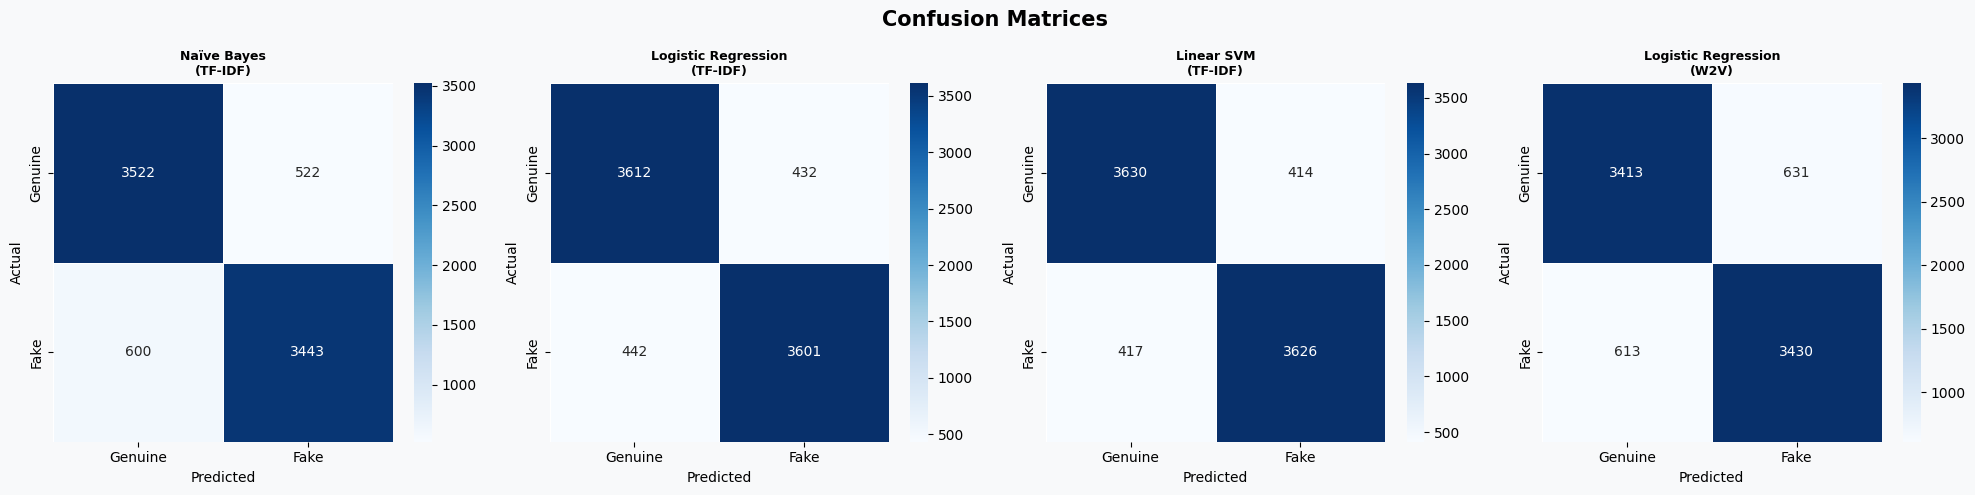

Figure saved: confusion_matrices.png


In [ ]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle('Confusion Matrices', fontsize=15, fontweight='bold')

for ax, (name, (clf, y_pred, _)) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Genuine','Fake'],
                yticklabels=['Genuine','Fake'],
                linewidths=0.5, linecolor='white')
    ax.set_title(name.replace(' (', '\n('), fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: confusion_matrices.png")


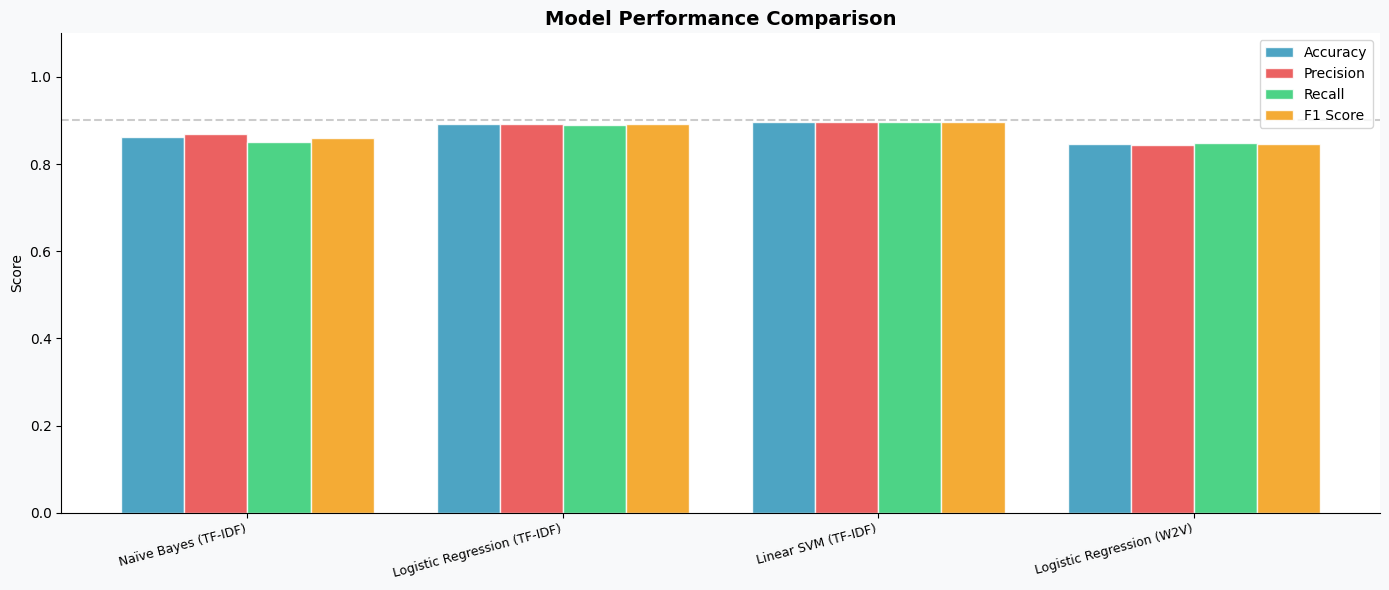


Best model by F1:
Model        Linear SVM (TF-IDF)
Accuracy                  0.8972
Precision                 0.8975
Recall                    0.8969
F1 Score                  0.8972
Name: 2, dtype: object


In [ ]:
# ── Model comparison bar chart ────────────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(results_df))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG_COLOR)
colors = ['#2E94B9', '#E84545', '#2ECC71', '#F39C12']

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width,
           label=metric, color=colors[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(loc='upper right')
ax.spines[['top','right']].set_visible(False)
ax.axhline(0.9, ls='--', color='grey', alpha=0.4, label='0.9 threshold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nBest model by F1:")
print(results_df.sort_values('F1 Score', ascending=False).iloc[0])


---
## Part 6 – Theory Questions (15 pts)

---

### Q1 – Difference between Text Classification and Text Clustering

**Text Classification** is a **supervised learning** task: a model is trained on
labelled examples (text + category) and learns to assign new, unseen texts to
predefined categories.  
*Example:* spam vs. ham detection; fake vs. genuine reviews.

**Text Clustering** is an **unsupervised learning** task: no labels are given.
The algorithm groups texts by similarity so that documents in the same cluster
are more alike than those in different clusters.  
*Example:* grouping thousands of news articles into thematic topics without
any prior labelling.

**Key distinction:** classification requires ground-truth labels and predicts
membership in a fixed label set; clustering discovers latent structure when
labels are unavailable or unknown.

> **Reference:**  
> Ahmed (2022). *Short Text Clustering Algorithms, Application and Challenges: A Survey*  
> Page 3, Section 3, third and fourth paragraph:   *"Differentiating between clustering and classification of documents is crucial [40]. Still, the difference between the two may be unclear because a set of documents must be split into groups in both cases. In general, labelled training data are supplied during classification;
however, the challenge arises when attempting to categorize test sets, which consist of unlabelled data, into a predetermined set of classes. In most cases, the classification problem may be handled using a supervised learning method [41,42].
As mentioned above, one of the significant challenges in clustering is grouping a set of unlabelled and non-predefined data into similar groups. Unsupervised learning methods are commonly used to solve the clustering problem. Furthermore, clustering is used in many data fields that do not rely on predefined knowledge of the data, unlike classification, which requires prior knowledge of the data [43]."*

---

### Q2 – When to Apply Text Clustering

Text clustering is appropriate when:

1. **No labelled data exists** – labelling is expensive or the categories are
   unknown in advance.  
2. **Exploratory analysis** – discovering hidden themes in large corpora
   (e.g., topic modelling on social-media posts after a disaster).  
3. **Dynamic taxonomies** – the number and nature of categories changes over
   time (e.g., clustering customer support tickets to surface emerging issues).  
4. **Recommendation & personalisation** – grouping users or items by textual
   similarity without predefined profiles.

*Use cases:* news topic discovery, customer-review theme extraction,
document organisation in digital libraries, patent landscaping.

> **Reference:**  
> Ahmed (2022). *Short Text Clustering Algorithms, Application and Challenges: A Survey*  
> Page 3, Section 3, third and fourth paragraph:   *"Differentiating between clustering and classification of documents is crucial [40]. Still, the difference between the two may be unclear because a set of documents must be split into groups in both cases. In general, labelled training data are supplied during classification;
however, the challenge arises when attempting to categorize test sets, which consist of unlabelled data, into a predetermined set of classes. In most cases, the classification problem may be handled using a supervised learning method [41,42].
As mentioned above, one of the significant challenges in clustering is grouping a set of unlabelled and non-predefined data into similar groups. Unsupervised learning methods are commonly used to solve the clustering problem. Furthermore, clustering is used in many data fields that do not rely on predefined knowledge of the data, unlike classification, which requires prior knowledge of the data [43]."*

---

### Q3 – Determining the Optimal Number of Clusters for K-Means

Two widely-used methods:

#### Method 1 – The Elbow Method
Plot the **Within-Cluster Sum of Squares (WCSS / inertia)** against the number
of clusters *k*.  
As *k* increases, WCSS decreases; when adding more clusters yields diminishing
returns, the curve forms an "elbow" – that inflection point is taken as the
optimal *k*.

#### Method 2 – Silhouette Score
For each sample, compute:  
`s(i) = (b(i) − a(i)) / max(a(i), b(i))`  
where *a(i)* = mean intra-cluster distance and *b(i)* = mean nearest-cluster
distance.  
The silhouette score ranges from −1 to +1; the value of *k* that maximises
the **mean silhouette score** across all samples is optimal.

> **Reference:**  
> Zhu, Li (1987). *Estimating the Number of Clusters in
High-Dimensional Large Datasets*  
> Section 1, p. 1 paragraph 1:  
> *"The elbow method (Thorndike, 1953) is a commonly used and intuitive method to estimate the number of clusters in a dataset. It performs k-means algorithm for each k in a given search space, then uses the sum of squared errors (SSE) (Arbelaitz et al., 2013) to draw the elbow graph, and determines the optimal number of clusters by judging the inflection point of the elbow graph. As the number of cluster k increases, the compactness of each cluster gradually increases, so the SSE gradually decreases. When k reaches the optimal number of clusters, the reduction of SSE decreases sharply, and then tends to be flat as the value of k continues to increase. The SSE is the sum of the distances of all entities to their cluster centers. The elbow method uses the SSE as the measure of clustering effectiveness because it can be derived directly from the k-means algorithm. However, the elbow method also has obvious downsides. First, it has to perform the k-means algorithm for each value of k in the search space R to get the SSE, which can be very computationally expensive for large datasets or high- dimensional datasets because it takes a lot of time to calculate the SSE before an estimate can be made. Secondly, the optimal number of clusters is "*

> **Reference:**  
> Rousseeuw, P. J. (1987). *Silhouettes: A graphical aid to the interpretation  
> and validation of cluster analysis.*  
> *Journal of Computational and Applied Mathematics, 20*, 53–65.  
> — Section 2, p. 55:  
> *"The silhouettes constructed below are useful when the proximities are on a ratio scale (as in the case of Euclidean distances) and when one is seeking compact and clearly separated clusters. Indeed, the definition makes use of average proximities as in the case of group average linkage, which is known to work best in a situation with roughly spherical clusters.
In order to construct silhouettes, we only need two things: the partition we have obtained (by the application of some clustering technique) and the collection of all proximities between objects. For each object i we will introduce a certain value s(i), and then these numbers are combined into a plot."*

---
## GitHub Repository Link

> 🔗 **https://github.com/uiilya/NLP-Fake-Reviews-Classification**
